# Fast Orbit Characterization

Orbit integration can be expensive when you only need basic orbital parameters
like eccentricity, pericenter, apocenter, or maximum height above the plane.
The Staeckel approximation provides a fast alternative that avoids integration
entirely. It also allows you to estimate the actions, angles, and frequencies of an orbit.

In [1]:
%matplotlib inline
import numpy
from galpy.orbit import Orbit
from galpy.potential import MWPotential2014
from galpy.actionAngle import estimateDeltaStaeckel
import warnings

warnings.filterwarnings("ignore", category=RuntimeWarning)
warnings.filterwarnings("ignore", category=UserWarning)

## Staeckel approximation for a single orbit

Use `analytic=True` with `type='staeckel'` to compute orbital parameters
without integrating. The Staeckel focal length `delta` is estimated
automatically.

In [2]:
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])

e_staeckel = o.e(analytic=True, pot=MWPotential2014, type="staeckel")
rap_staeckel = o.rap(analytic=True, pot=MWPotential2014, type="staeckel")
rperi_staeckel = o.rperi(analytic=True, pot=MWPotential2014, type="staeckel")
zmax_staeckel = o.zmax(analytic=True, pot=MWPotential2014, type="staeckel")

print(f"Eccentricity: {e_staeckel:.4f}")
print(f"Apocenter:    {rap_staeckel:.4f}")
print(f"Pericenter:   {rperi_staeckel:.4f}")
print(f"zmax:         {zmax_staeckel:.4f}")

Eccentricity: 0.0749
Apocenter:    1.0845
Pericenter:   0.9333
zmax:         0.0431


Note that ``type='staeckel'`` is the default when `analytic=True`, so you can omit it if you want.

## Multiple orbits at once

The Staeckel approximation works efficiently for arrays of orbits.

In [3]:
numpy.random.seed(42)
N = 1000
vxvvs = numpy.column_stack(
    [
        numpy.random.uniform(0.5, 1.5, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.uniform(0.8, 1.2, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.uniform(0.0, 2 * numpy.pi, N),
    ]
)
os = Orbit(vxvvs)
eccs = os.e(analytic=True, pot=MWPotential2014, type="staeckel")
print(f"Computed {len(eccs)} eccentricities")
print(f"Mean eccentricity: {numpy.mean(eccs):.4f}")
print(f"Std eccentricity:  {numpy.std(eccs):.4f}")

Computed 1000 eccentricities
Mean eccentricity: 0.1338
Std eccentricity:  0.0635


## Estimating the Staeckel focal length

The `estimateDeltaStaeckel` function computes the optimal focal
length `delta` for a given position in a potential. This is done
automatically by the orbit methods, but you can also call it directly.

In [4]:
# For a single position
delta = estimateDeltaStaeckel(MWPotential2014, 1.0, 0.1)
print(f"Estimated delta: {delta:.4f}")

# For an array of positions
Rs = numpy.random.uniform(0.5, 1.5, 100)
zs = numpy.random.normal(0.0, 0.1, 100)
deltas = estimateDeltaStaeckel(MWPotential2014, Rs, zs)
print(f"Mean delta: {numpy.mean(deltas):.4f}")

Estimated delta: 0.4033
Mean delta: 0.4502


## Comparison: numerical vs. Staeckel

Let's compare orbital parameters computed by orbit integration vs.
the Staeckel approximation.

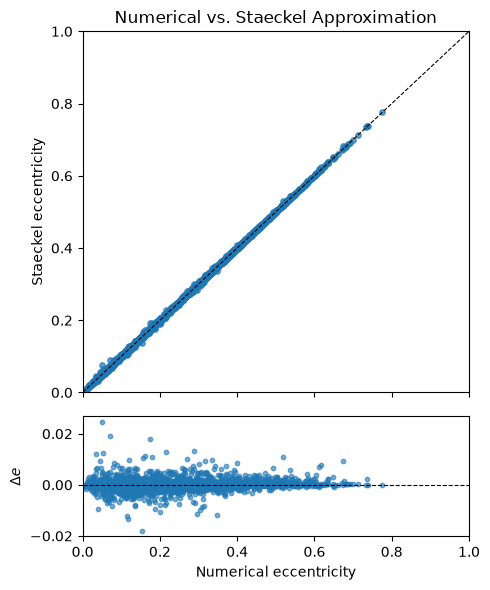

In [5]:
import matplotlib.pyplot as plt

numpy.random.seed(42)
N_cmp = 5000
vxvvs_cmp = numpy.column_stack(
    [
        numpy.random.uniform(0.6, 2.4, N_cmp),
        numpy.random.normal(0.0, 0.28, N_cmp),
        numpy.random.uniform(0.85, 1.15, N_cmp),
        numpy.random.uniform(0.01, 0.2, N_cmp),
        numpy.random.normal(0.0, 0.28, N_cmp),
        numpy.random.uniform(0.0, 2 * numpy.pi, N_cmp),
    ]
)
os_cmp = Orbit(vxvvs_cmp)

# Numerical: integrate then compute
ts = numpy.linspace(0.0, 50.0, 5_000)
os_cmp.integrate(ts, MWPotential2014)
e_num = os_cmp.e()

# Staeckel: no integration needed
e_ana = os_cmp.e(analytic=True, pot=MWPotential2014)

# Two-panel comparison with shared x-axis
fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, sharex=True, figsize=(5, 6), gridspec_kw={"height_ratios": [3, 1]}
)

# Top: direct comparison
ax_top.plot([0, 1], [0, 1], "k--", lw=0.8)
ax_top.scatter(e_num, e_ana, s=15, alpha=0.7)
ax_top.set_ylabel("Staeckel eccentricity")
ax_top.set_title("Numerical vs. Staeckel Approximation")
ax_top.set_xlim(0, 1.0)
ax_top.set_ylim(0, 1.0)

# Bottom: difference
diff = e_ana - e_num
ax_bot.axhline(0.0, color="k", ls="--", lw=0.8)
ax_bot.scatter(e_num, diff, s=10, alpha=0.6)
ax_bot.set_xlabel("Numerical eccentricity")
ax_bot.set_ylabel(r"$\Delta e$")

plt.tight_layout()

## Actions, angles, and frequencies

The Staeckel approximation also provides estimates of the actions, angles, and frequencies of an orbit (see [Binney 2012](https://ui.adsabs.harvard.edu/abs/2012MNRAS.426.1324B/abstract)). This is discussed in more detail in the [Staeckel Approximation](../action_angle/staeckel.ipynb) tutorial, but we can also compute these quantities when `analytic=True`:

In [6]:
o = Orbit([1.0, 0.1, 1.0, 0.0, 0.1, 0.0])

jr_staeckel = o.jr(analytic=True, pot=MWPotential2014, type="staeckel")
jz_staeckel = o.jz(analytic=True, pot=MWPotential2014, type="staeckel")

print(f"Radial action: {jr_staeckel:.4f}")
print(f"Vertical action: {jz_staeckel:.4f}")

Radial action: 0.0038
Vertical action: 0.0020


Note that the angular momentum is the third action, so it is exact regardless of the approximation used:

In [7]:
lz = o.Lz()
print(f"Angular momentum: {lz:.4f}")

Angular momentum: 1.0000


We can also return actions with physical units, e.g.,

In [8]:
o.turn_physical_on(8.0, 220.0)
jr_staeckel = o.jr(analytic=True, pot=MWPotential2014, quantity=True)
jz_staeckel = o.jz(analytic=True, pot=MWPotential2014, quantity=True)

print(f"Radial action: {jr_staeckel:.4f}")
print(f"Vertical action: {jz_staeckel:.4f}")

Radial action: 6.6471 km kpc / s
Vertical action: 3.5010 km kpc / s


Like for the basic orbital properties, we can also quickly estimate actions for many 
orbits at once using the Staeckel approximation:

In [9]:
import time

numpy.random.seed(42)
N = 1000
vxvvs = numpy.column_stack(
    [
        numpy.random.uniform(0.5, 1.5, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.uniform(0.8, 1.2, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.normal(0.0, 0.1, N),
        numpy.random.uniform(0.0, 2 * numpy.pi, N),
    ]
)
os = Orbit(vxvvs, ro=8.0, vo=220.0)
start = time.time()
jrs = os.jr(analytic=True, pot=MWPotential2014, quantity=True)
end = time.time()
print(f"Computed {len(jrs)} radial actions")
print(f"Time taken: {end - start:.4f} seconds")
print(f"Mean radial action: {numpy.mean(jrs):.4f}")
print(f"Std radial action:  {numpy.std(jrs):.4f}")

Computed 1000 radial actions
Time taken: 0.3125 seconds
Mean radial action: 29.2508 km kpc / s
Std radial action:  32.1806 km kpc / s


The orbit interface also allows orbital frequencies and angles to be computed in the same way, but we won't show that here. See the [Staeckel Approximation](../action_angle/staeckel.ipynb) tutorial for examples of that.

For a real-world application of fast orbit characterization to a large observational
dataset, see the [thick-disk eccentricity distribution example](./examples.ipynb#The-eccentricity-distribution-of-the-Milky-Way's-thick-disk)
in the Orbit Examples notebook.